# **Import Libraries**

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# **Load Dataset**

In [148]:
df = pd.read_csv("Zara_sales_EDA.csv")
df.head()

,Product ID;Product Position;Promotion;Product Category;Seasonal;Sales Volume;brand;url;name;description;price;currency;terms;section;season;material;origin
0,185102;Aisle;Yes;clothing;Yes;1243;Zara;https:...
1,188771;Aisle;Yes;clothing;No;1429;Zara;https:/...
2,180176;End-cap;Yes;clothing;Yes;1168;Zara;http...
3,112917;Aisle;Yes;clothing;No;1348;Zara;https:/...
4,192936;End-cap;Yes;clothing;Yes;1602;Zara;http...


# **Data Preprocessing**

# Fixing Data

In [151]:
df = df['Product ID;Product Position;Promotion;Product Category;Seasonal;Sales Volume;brand;url;name;description;price;currency;terms;section;season;material;origin'].str.split(';', expand=True)

In [152]:
df.rename(columns={0 : "Product ID",
                  1 : "Product Position",
                  2 : "Promotion",
                  3 : "Product Category",
                  4 : "Seasonal",
                  5 : "Sales Volume",
                  6 : "Brand",
                  7 : "URL",
                  8 : "Name",
                  9 : "Description",
                  10 : "Price",
                  11 : "Currency",
                  12 : "Terms",
                  13 : "Section",
                  14 : "Season",
                  15 : "Material",16  : "Origin"}, inplace=True)

df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,Brand,URL,Name,Description,Price,Currency,Terms,Section,Season,Material,Origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


# Dropping Useless Features

In [154]:
df['Product Category'].value_counts()

Product Category
clothing    20252
Name: count, dtype: int64

In [155]:
df['Brand'].value_counts()

Brand
Zara    20252
Name: count, dtype: int64

In [156]:
df['Currency'].value_counts()

Currency
USD    20252
Name: count, dtype: int64

In [157]:
df['Seasonal'].value_counts()

Seasonal
No     10136
Yes    10116
Name: count, dtype: int64

These features have only one unique value. so, we don't need them in the analysis

In [159]:
dropped_columns = ['Product ID', 'URL', 'Description', 'Brand', 'Currency', 'Product Category', 'Seasonal']

df.drop(columns = dropped_columns, inplace=True)

In [160]:
df.head()

,Product Position,Promotion,Sales Volume,Name,Price,Terms,Section,Season,Material,Origin
0,Aisle,Yes,1243,BASIC PUFFER JACKET,78.99,jackets,MAN,Winter,Polyester,Brazil
1,Aisle,Yes,1429,TUXEDO JACKET,14.99,jackets,MAN,Autumn,Cotton,Turkey
2,End-cap,Yes,1168,SLIM FIT SUIT JACKET,71.95,jackets,WOMAN,Autumn,Polyester,Morocco
3,Aisle,Yes,1348,STRETCH SUIT JACKET,30.99,jackets,MAN,Spring,Polyester,China
4,End-cap,Yes,1602,DOUBLE FACED JACKET,22.99,jackets,WOMAN,Winter,Wool Blend,China


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product Position  20252 non-null  object
 1   Promotion         20252 non-null  object
 2   Sales Volume      20252 non-null  object
 3   Name              20252 non-null  object
 4   Price             20252 non-null  object
 5   Terms             20252 non-null  object
 6   Section           20252 non-null  object
 7   Season            20252 non-null  object
 8   Material          20252 non-null  object
 9   Origin            20252 non-null  object
dtypes: object(10)
memory usage: 1.5+ MB


# Fixing Features Data Types

In [163]:
df['Sales Volume'] = df['Sales Volume'].astype(int)
df['Promotion'] = df['Sales Volume'].astype(bool)
df['Price'] = df['Sales Volume'].astype(float)

# Feature Engineering

In [166]:
df['revenue'] = df['Price'] * df['Sales Volume']

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Position  20252 non-null  object 
 1   Promotion         20252 non-null  bool   
 2   Sales Volume      20252 non-null  int32  
 3   Name              20252 non-null  object 
 4   Price             20252 non-null  float64
 5   Terms             20252 non-null  object 
 6   Section           20252 non-null  object 
 7   Season            20252 non-null  object 
 8   Material          20252 non-null  object 
 9   Origin            20252 non-null  object 
 10  revenue           20252 non-null  float64
dtypes: bool(1), float64(2), int32(1), object(7)
memory usage: 1.5+ MB


# **Exploratory Data Analysis**

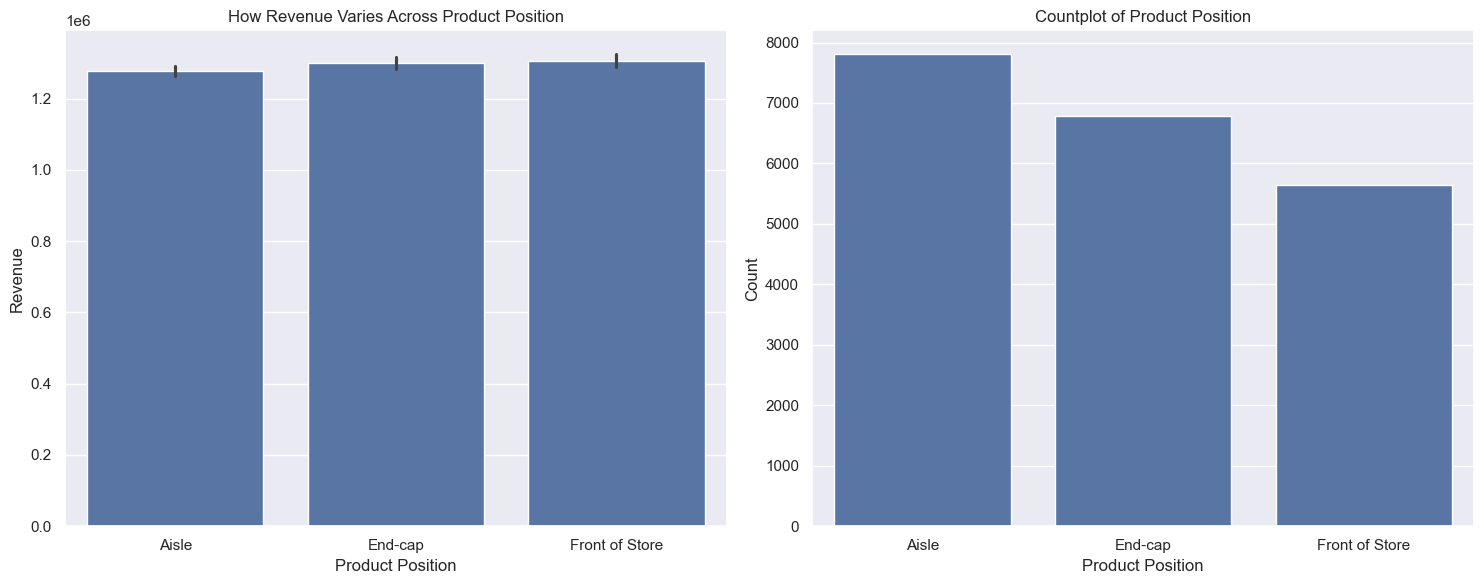

In [271]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Product Position', y='revenue', data=df, ax=axes[0])
axes[0].set_title('How Revenue Varies Across Product Position')
axes[0].set_xlabel('Product Position')
axes[0].set_ylabel('Revenue')

sns.countplot(x='Product Position', data=df, ax=axes[1])
axes[1].set_title('Countplot of Product Position')
axes[1].set_xlabel('Product Position')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Even though most of sold products are located on Aisle, products sold from the front of the store have higher revenue.

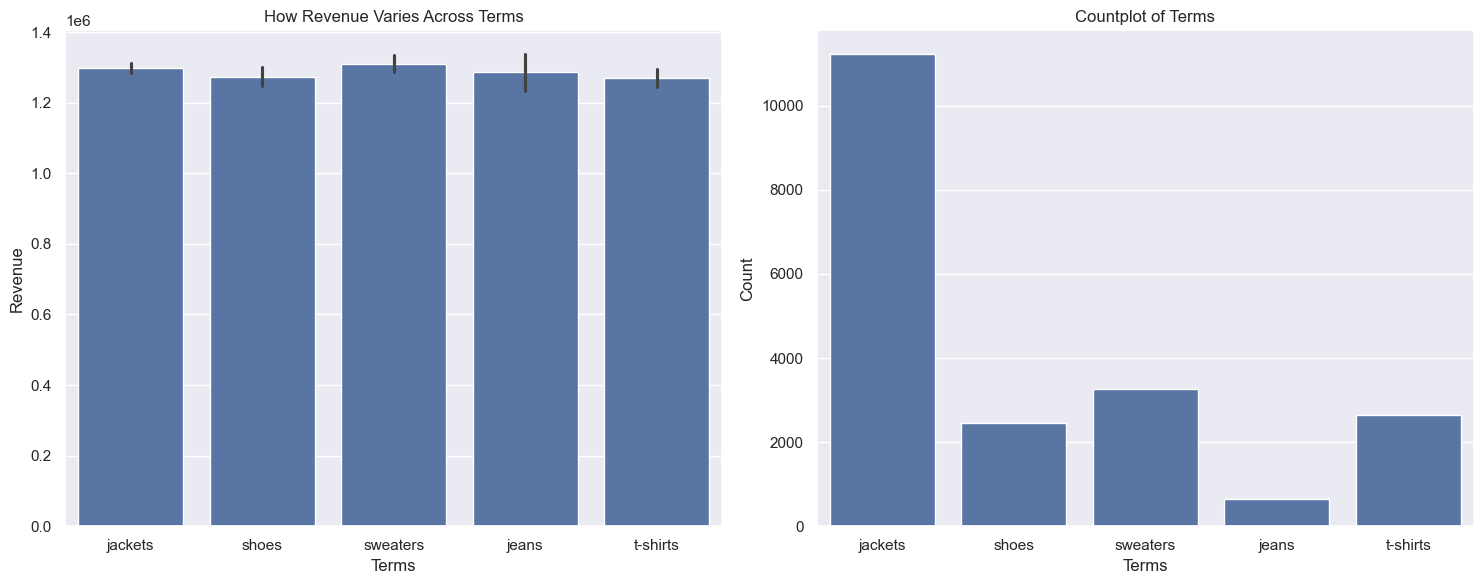

In [267]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Terms', y='revenue', data=df, ax=axes[0])
axes[0].set_title('How Revenue Varies Across Terms')
axes[0].set_xlabel('Terms')
axes[0].set_ylabel('Revenue')

sns.countplot(x='Terms', data=df, ax=axes[1])
axes[1].set_title('Countplot of Terms')
axes[1].set_xlabel('Terms')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

- The majority of the products fall under 'jakets' category, while really few number of them are 'jeans'
- 'sweaters' are the highest with respect to revenue in comparison to the other categories

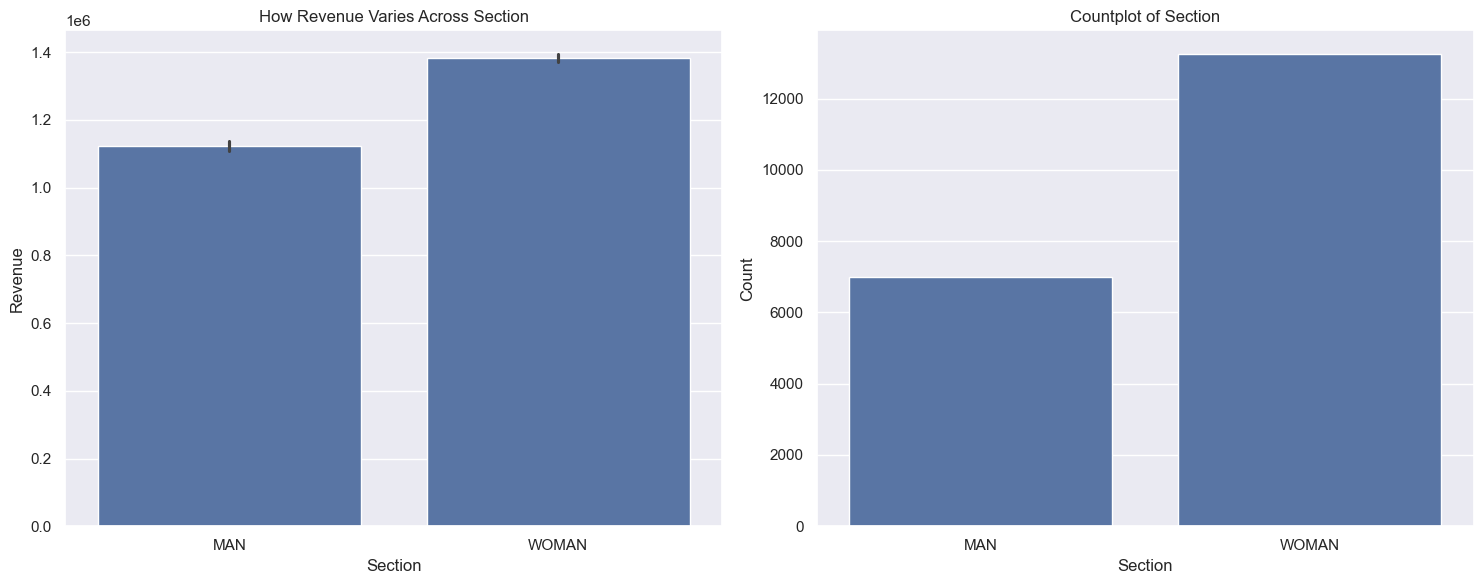

In [269]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Section', y='revenue', data=df, ax=axes[0])
axes[0].set_title('How Revenue Varies Across Section')
axes[0].set_xlabel('Section')
axes[0].set_ylabel('Revenue')

sns.countplot(x='Section', data=df, ax=axes[1])
axes[1].set_title('Countplot of Section')
axes[1].set_xlabel('Section')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Most of the sold products with highest revenue are from women section

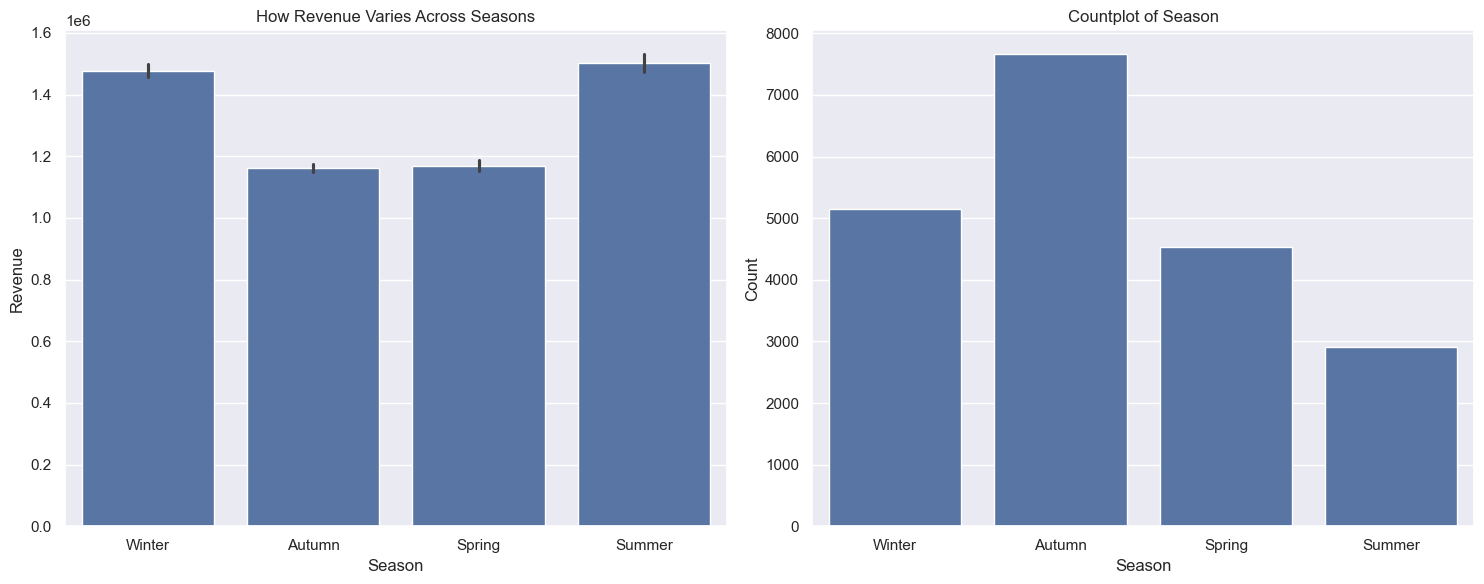

In [263]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Season', y='revenue', data=df, ax=axes[0])
axes[0].set_title('How Revenue Varies Across Seasons')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Revenue')

sns.countplot(x='Season', data=df, ax=axes[1])
axes[1].set_title('Countplot of Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

- The majority of the sold products are 'Autumn' seasoned, while the least are 'Summer' seasoned
- Summer and winter are the highest seasons with respect to revenue, respectively
- even tho the majority is sold in autumn, it

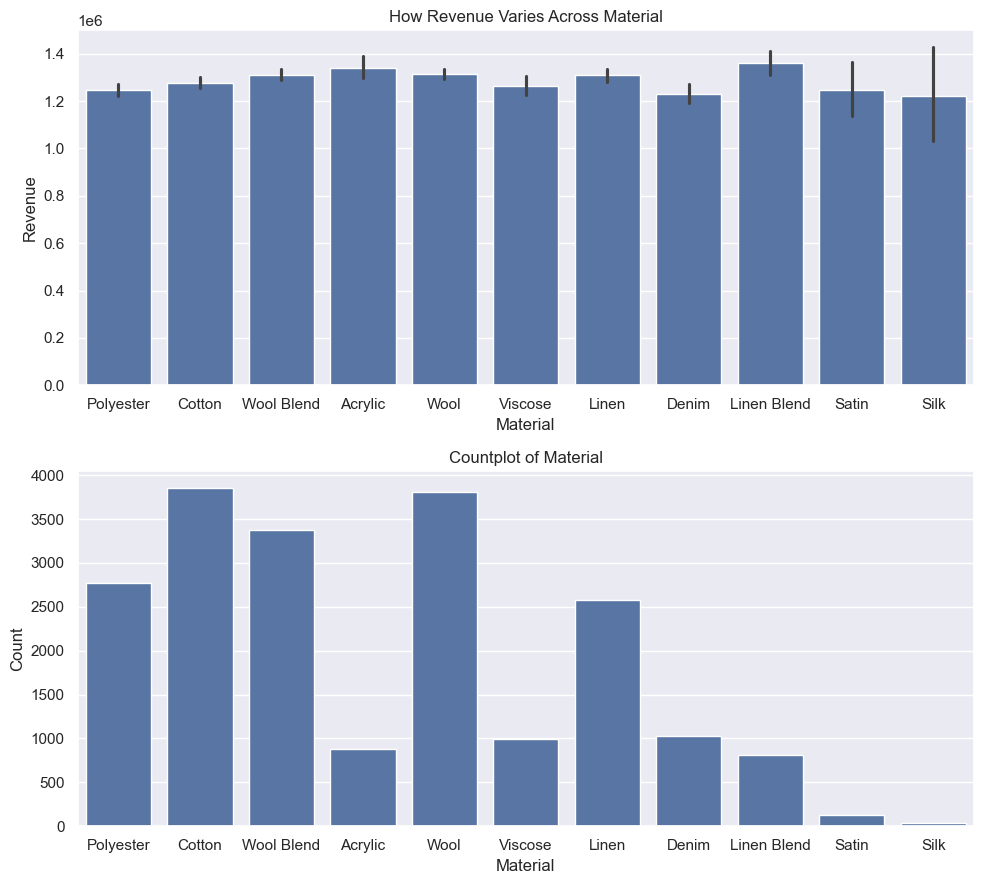

In [278]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

sns.barplot(x='Material', y='revenue', data=df, ax=axes[0])
axes[0].set_title('How Revenue Varies Across Material')
axes[0].set_xlabel('Material')
axes[0].set_ylabel('Revenue')

sns.countplot(x='Material', data=df, ax=axes[1])
axes[1].set_title('Countplot of Material')
axes[1].set_xlabel('Material')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

- Most sold products are made of "cotton," "wool," "wool blend," and "Polyester," while a relatively small number of them are made of "silk."
- in another hand, products made from 'Linen Blend,' 'Acrylic,' 'linen,' are the ones that produce higher revenue

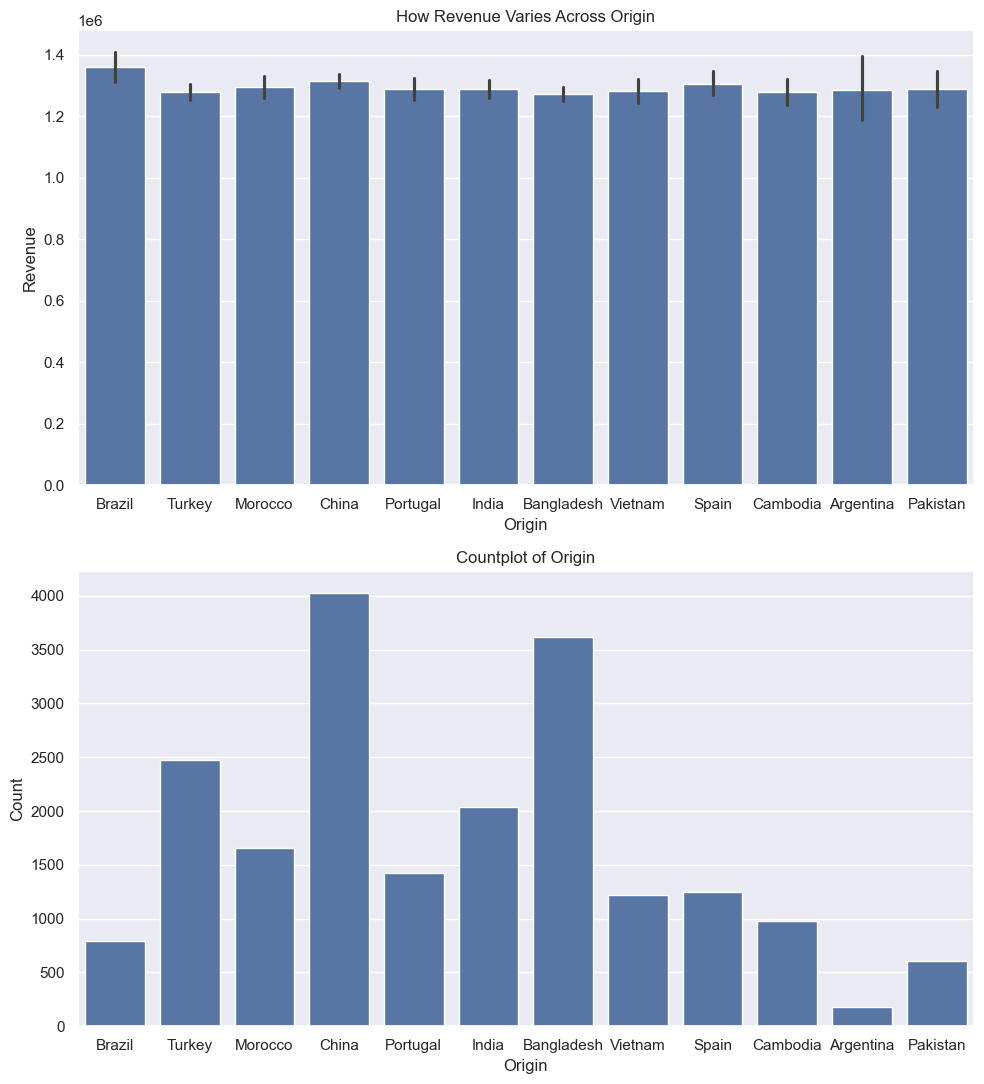

In [289]:
fig, axes = plt.subplots(2, 1, figsize=(10, 11))

sns.barplot(x='Origin', y='revenue', data=df, ax=axes[0])
axes[0].set_title('How Revenue Varies Across Origin')
axes[0].set_xlabel('Origin')
axes[0].set_ylabel('Revenue')

sns.countplot(x='Origin', data=df, ax=axes[1])
axes[1].set_title('Countplot of Origin')
axes[1].set_xlabel('Origin')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

- China has the highest activity when it comes to selling products
- While, Brazil has the highest revenue among all other countries.

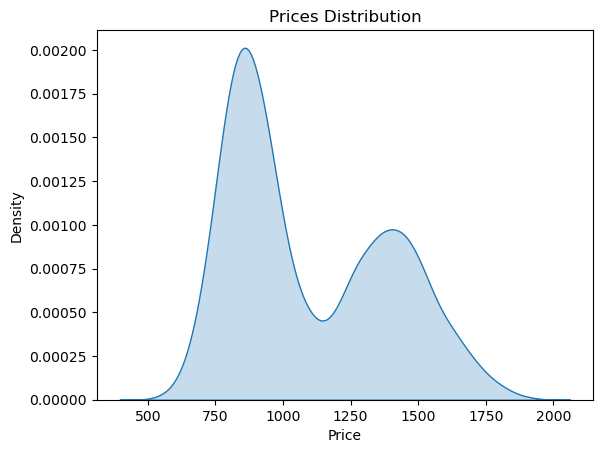

In [179]:
sns.kdeplot(df['Price'], fill=True)
plt.title('Prices Distribution')
plt.show()

The majority of the prices range between 750 and 1000

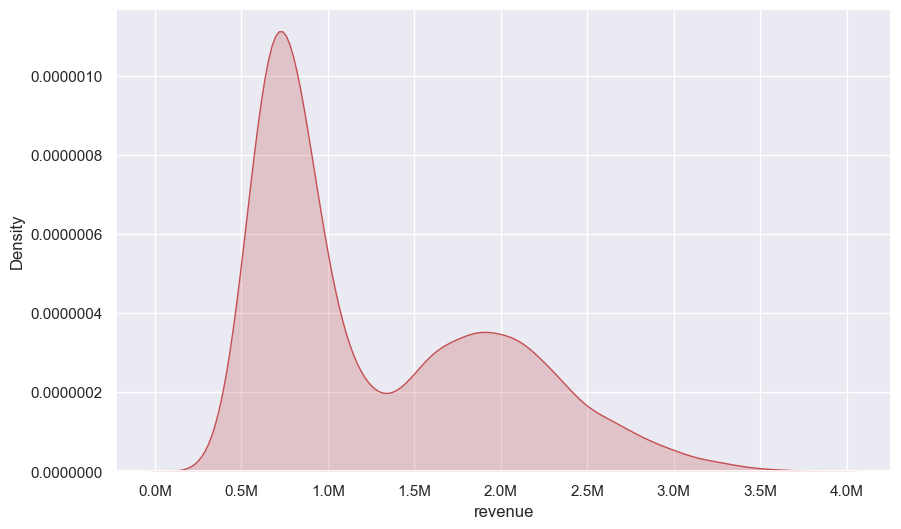

In [301]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['revenue'], fill=True, color="r")

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
ax.ticklabel_format(style='plain', axis='y') 

plt.show()

- The standard spot is around 750k, which makes it the average, or most frequent.
- There exists a specific group of products that all hit around 2 million
- between 1.25 and 1.5 million is considered no-man land, which means that the majority of the products either fall between the standard or premium range, really low number falls in the average-range.

In [304]:
df.to_csv("Zara_sales_dataset_preprocessed.csv")